# Logistic Regression — Complete Notes

Merged notes on Logistic Regression: the algorithm implemented from scratch with NumPy, followed by a full applied workflow using scikit-learn (feature engineering, pipelines, training, and evaluation) on the Titanic dataset.

- **Part 1:** Logistic Regression from Scratch (NumPy)
- **Part 2:** Logistic Regression with Scikit-Learn (End-to-End Pipeline)

---
## Part 1: Logistic Regression from Scratch (NumPy)

# Logistic Regression from Scratch
This notebook demonstrates how to implement a basic logistic regression model using NumPy. We will define the model, calculate costs, and use gradient descent to optimize our parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## 1. Data Preparation
We define a small dataset where features represent `age` and `ticket price`, and the target `y` represents a binary outcome (e.g., whether a pessenger will survive or not).

In [2]:
# Define features: column 0 is Age, column 1 is Ticket Price
X = np.array([
    [10 , 3 ],
    [20 , 5 ],
    [35, 20],
    [50, 10],
])

# Define target labels: 0 (did not survive), 1 (survived)
y = np.array([0, 0, 1, 1])

## 2. The Sigmoid Function
The sigmoid function maps any input value to a range between 0 and 1, which we interpret as a probability.

In [3]:
def sigmoid(z):
  """
  Computes the sigmoid of z.
  Args:
      z: A scalar or numpy array of any size.
  Returns:
      s: sigmoid(z)
  """
  return 1 / (1 + np.exp(-z))

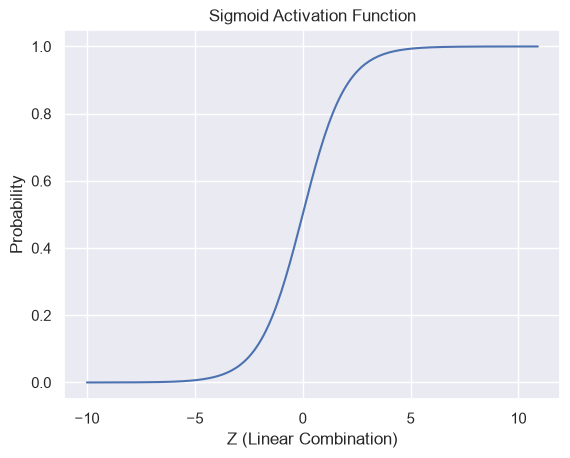

In [4]:
# Create an array of values from -10 to 10 to visualize the S-curve
z = np.arange(-10, 11, 0.1)
sigmoid_values = sigmoid(z)

# Plot the sigmoid function
plt.plot(z, sigmoid_values)
plt.title("Sigmoid Activation Function")
plt.xlabel("Z (Linear Combination)")
plt.ylabel("Probability")
plt.grid(True)

## 3. Making Predictions
We use our weights ($W$) and bias ($b$) to compute $z = W \cdot X + b$, then pass it through the sigmoid function to get probabilities. A threshold (usually 0.5) is used to decide the final class.

In [5]:
# Initialize weights (W) and bias (b) with arbitrary small values to test the prediction logic
w_init = np.array([0.5, -2])
b_init = 0.01

In [6]:
def make_prediction(X, W, b, threshold=0.5):
  """
  Calculates the model output for each example in X.
  """
  m = X.shape[0]
  prob_list = np.zeros((m,))

  for i in range(m):
    # Calculate z = w1*x1 + w2*x2 + ... + b
    z = np.dot(W, X[i]) + b
    # Convert z into a probability
    prob_list[i] = sigmoid(z)

  # If probability > threshold, return True (1), else False (0)
  prediction = (prob_list > threshold)
  return prediction

# Test with initial weights
print("Initial Predictions:", make_prediction(X, w_init, b_init))

Initial Predictions: [False  True False  True]


## 4. Cost Function
To train the model, we need to measure how 'wrong' it is. We use the Log Loss (or Binary Cross-Entropy) cost function.

In [7]:
def compute_cost(X, y, W, b):
  """
  Computes the Binary Cross-Entropy Cost.
  """
  m = X.shape[0]
  total_cost = 0.0

  for i in range(m):
    z = np.dot(W, X[i]) + b
    prob = sigmoid(z)
    # Log Loss formula: -[y*log(p) + (1-y)*log(1-p)]
    # We sum the inner part here and negate later
    total_cost += (y[i] * np.log(prob)) + ((1 - y[i]) * np.log(1 - prob))

  # Average the cost and negate
  return total_cost / (-m)

print(f"Initial Cost: {compute_cost(X, y, w_init, b_init):.4f}")

Initial Cost: 5.8777


## 5. Gradient Computation
The gradient tells us the direction and magnitude of the change needed for $W$ and $b$ to reduce the cost.

In [8]:
# This cell is a placeholder for gradient utility functions if needed.
# Currently, calculate_gradient handles the main logic below.

In [9]:
def calculate_gradient(X, y, W, b):
  """
  Computes the partial derivatives of the cost w.r.t parameters.
  """
  m, n = X.shape
  dj_dw = np.zeros((n,))
  dj_db = 0.0

  for i in range(m):
    z = np.dot(W, X[i]) + b
    prob = sigmoid(z)
    # Difference between prediction and actual label
    error = prob - y[i]

    # Gradient for bias
    dj_db += error

    # Gradient for each weight
    for j in range(n):
      dj_dw[j] += error * X[i, j]

  # Return average gradients
  return dj_dw / m, dj_db / m

## 6. Gradient Descent
This is the optimization loop where we repeatedly calculate gradients and update our parameters to find the minimum cost.

In [10]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """
  Optimizes W and b by moving in the direction of steepest descent.
  """
  w = w_input
  b = b_input
  cost_history = []

  for i in range(max_iter):
    # Step 1: Compute gradients
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # Step 2: Update parameters (w = w - learning_rate * gradient)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # Step 3: Record the cost to monitor convergence
    if i % 100 == 0:
      cost = compute_cost(X, y, w, b)
      cost_history.append(cost)
      print(f"Iter {i}: Cost {cost:.4f}")

  return w, b, cost_history

In [11]:
# Get number of features from X
n = X.shape[1]

# Reset W and b to zeros for a clean training start
W_init = np.zeros((n,))
b_init = 0.0

# Run Gradient Descent: find optimal weights and bias
# We use a large number of iterations (100,000) and a small learning rate (0.01)
w_final, b_final, cost_history = gradient_descent(X, y, w_input=W_init, b_input=b_init, max_iter=100000, alpha=0.01)

Iter 0: Cost 0.7342
Iter 100: Cost 0.5275
Iter 200: Cost 0.4928
Iter 300: Cost 0.4614
Iter 400: Cost 0.4330
Iter 500: Cost 0.4073
Iter 600: Cost 0.3840
Iter 700: Cost 0.3629
Iter 800: Cost 0.3436
Iter 900: Cost 0.3260
Iter 1000: Cost 0.3099
Iter 1100: Cost 0.2952
Iter 1200: Cost 0.2817
Iter 1300: Cost 0.2693
Iter 1400: Cost 0.2578
Iter 1500: Cost 0.2472
Iter 1600: Cost 0.2374
Iter 1700: Cost 0.2283
Iter 1800: Cost 0.2198
Iter 1900: Cost 0.2119
Iter 2000: Cost 0.2045
Iter 2100: Cost 0.1976
Iter 2200: Cost 0.1911
Iter 2300: Cost 0.1851
Iter 2400: Cost 0.1794
Iter 2500: Cost 0.1740
Iter 2600: Cost 0.1689
Iter 2700: Cost 0.1641
Iter 2800: Cost 0.1596
Iter 2900: Cost 0.1553
Iter 3000: Cost 0.1512
Iter 3100: Cost 0.1473
Iter 3200: Cost 0.1436
Iter 3300: Cost 0.1401
Iter 3400: Cost 0.1368
Iter 3500: Cost 0.1336
Iter 3600: Cost 0.1305
Iter 3700: Cost 0.1276
Iter 3800: Cost 0.1248
Iter 3900: Cost 0.1222
Iter 4000: Cost 0.1196
Iter 4100: Cost 0.1172
Iter 4200: Cost 0.1148
Iter 4300: Cost 0.1126


Iter 4600: Cost 0.1063
Iter 4700: Cost 0.1043
Iter 4800: Cost 0.1025
Iter 4900: Cost 0.1006
Iter 5000: Cost 0.0989
Iter 5100: Cost 0.0972
Iter 5200: Cost 0.0956
Iter 5300: Cost 0.0940
Iter 5400: Cost 0.0925
Iter 5500: Cost 0.0910
Iter 5600: Cost 0.0896
Iter 5700: Cost 0.0882
Iter 5800: Cost 0.0869


Iter 5900: Cost 0.0856
Iter 6000: Cost 0.0843
Iter 6100: Cost 0.0831
Iter 6200: Cost 0.0819
Iter 6300: Cost 0.0807
Iter 6400: Cost 0.0796
Iter 6500: Cost 0.0785
Iter 6600: Cost 0.0774
Iter 6700: Cost 0.0764
Iter 6800: Cost 0.0754
Iter 6900: Cost 0.0744
Iter 7000: Cost 0.0735
Iter 7100: Cost 0.0725
Iter 7200: Cost 0.0716
Iter 7300: Cost 0.0707
Iter 7400: Cost 0.0699
Iter 7500: Cost 0.0690
Iter 7600: Cost 0.0682
Iter 7700: Cost 0.0674
Iter 7800: Cost 0.0666
Iter 7900: Cost 0.0658
Iter 8000: Cost 0.0651
Iter 8100: Cost 0.0644
Iter 8200: Cost 0.0636
Iter 8300: Cost 0.0629
Iter 8400: Cost 0.0623
Iter 8500: Cost 0.0616
Iter 8600: Cost 0.0609
Iter 8700: Cost 0.0603
Iter 8800: Cost 0.0597
Iter 8900: Cost 0.0591


Iter 9000: Cost 0.0585
Iter 9100: Cost 0.0579
Iter 9200: Cost 0.0573
Iter 9300: Cost 0.0567
Iter 9400: Cost 0.0562
Iter 9500: Cost 0.0556
Iter 9600: Cost 0.0551
Iter 9700: Cost 0.0546
Iter 9800: Cost 0.0540
Iter 9900: Cost 0.0535
Iter 10000: Cost 0.0530
Iter 10100: Cost 0.0526
Iter 10200: Cost 0.0521
Iter 10300: Cost 0.0516


Iter 10400: Cost 0.0512
Iter 10500: Cost 0.0507
Iter 10600: Cost 0.0503
Iter 10700: Cost 0.0498
Iter 10800: Cost 0.0494
Iter 10900: Cost 0.0490
Iter 11000: Cost 0.0486
Iter 11100: Cost 0.0482
Iter 11200: Cost 0.0478
Iter 11300: Cost 0.0474
Iter 11400: Cost 0.0470
Iter 11500: Cost 0.0466
Iter 11600: Cost 0.0462
Iter 11700: Cost 0.0459
Iter 11800: Cost 0.0455
Iter 11900: Cost 0.0451
Iter 12000: Cost 0.0448
Iter 12100: Cost 0.0444
Iter 12200: Cost 0.0441
Iter 12300: Cost 0.0438
Iter 12400: Cost 0.0434
Iter 12500: Cost 0.0431
Iter 12600: Cost 0.0428
Iter 12700: Cost 0.0425
Iter 12800: Cost 0.0422
Iter 12900: Cost 0.0419
Iter 13000: Cost 0.0415
Iter 13100: Cost 0.0413


Iter 13200: Cost 0.0410
Iter 13300: Cost 0.0407
Iter 13400: Cost 0.0404
Iter 13500: Cost 0.0401
Iter 13600: Cost 0.0398
Iter 13700: Cost 0.0396
Iter 13800: Cost 0.0393
Iter 13900: Cost 0.0390
Iter 14000: Cost 0.0388


Iter 14100: Cost 0.0385
Iter 14200: Cost 0.0382
Iter 14300: Cost 0.0380
Iter 14400: Cost 0.0377
Iter 14500: Cost 0.0375
Iter 14600: Cost 0.0373
Iter 14700: Cost 0.0370
Iter 14800: Cost 0.0368
Iter 14900: Cost 0.0365
Iter 15000: Cost 0.0363
Iter 15100: Cost 0.0361
Iter 15200: Cost 0.0359
Iter 15300: Cost 0.0356
Iter 15400: Cost 0.0354
Iter 15500: Cost 0.0352
Iter 15600: Cost 0.0350
Iter 15700: Cost 0.0348
Iter 15800: Cost 0.0346
Iter 15900: Cost 0.0344
Iter 16000: Cost 0.0342
Iter 16100: Cost 0.0340
Iter 16200: Cost 0.0338
Iter 16300: Cost 0.0336
Iter 16400: Cost 0.0334
Iter 16500: Cost 0.0332
Iter 16600: Cost 0.0330
Iter 16700: Cost 0.0328
Iter 16800: Cost 0.0326
Iter 16900: Cost 0.0324
Iter 17000: Cost 0.0323
Iter 17100: Cost 0.0321
Iter 17200: Cost 0.0319
Iter 17300: Cost 0.0317
Iter 17400: Cost 0.0316
Iter 17500: Cost 0.0314
Iter 17600: Cost 0.0312
Iter 17700: Cost 0.0311
Iter 17800: Cost 0.0309
Iter 17900: Cost 0.0307
Iter 18000: Cost 0.0306
Iter 18100: Cost 0.0304
Iter 18200: Cost

Iter 19700: Cost 0.0281
Iter 19800: Cost 0.0279
Iter 19900: Cost 0.0278
Iter 20000: Cost 0.0276
Iter 20100: Cost 0.0275
Iter 20200: Cost 0.0274
Iter 20300: Cost 0.0273
Iter 20400: Cost 0.0271
Iter 20500: Cost 0.0270
Iter 20600: Cost 0.0269
Iter 20700: Cost 0.0268
Iter 20800: Cost 0.0266
Iter 20900: Cost 0.0265


Iter 21000: Cost 0.0264
Iter 21100: Cost 0.0263
Iter 21200: Cost 0.0262
Iter 21300: Cost 0.0260
Iter 21400: Cost 0.0259
Iter 21500: Cost 0.0258
Iter 21600: Cost 0.0257
Iter 21700: Cost 0.0256
Iter 21800: Cost 0.0255
Iter 21900: Cost 0.0254
Iter 22000: Cost 0.0252
Iter 22100: Cost 0.0251
Iter 22200: Cost 0.0250
Iter 22300: Cost 0.0249
Iter 22400: Cost 0.0248
Iter 22500: Cost 0.0247
Iter 22600: Cost 0.0246
Iter 22700: Cost 0.0245
Iter 22800: Cost 0.0244
Iter 22900: Cost 0.0243
Iter 23000: Cost 0.0242
Iter 23100: Cost 0.0241
Iter 23200: Cost 0.0240
Iter 23300: Cost 0.0239
Iter 23400: Cost 0.0238
Iter 23500: Cost 0.0237
Iter 23600: Cost 0.0236
Iter 23700: Cost 0.0235
Iter 23800: Cost 0.0234
Iter 23900: Cost 0.0233
Iter 24000: Cost 0.0232
Iter 24100: Cost 0.0231
Iter 24200: Cost 0.0230
Iter 24300: Cost 0.0230
Iter 24400: Cost 0.0229
Iter 24500: Cost 0.0228
Iter 24600: Cost 0.0227
Iter 24700: Cost 0.0226
Iter 24800: Cost 0.0225
Iter 24900: Cost 0.0224
Iter 25000: Cost 0.0223
Iter 25100: Cost

Iter 25400: Cost 0.0220
Iter 25500: Cost 0.0219
Iter 25600: Cost 0.0218
Iter 25700: Cost 0.0218
Iter 25800: Cost 0.0217
Iter 25900: Cost 0.0216
Iter 26000: Cost 0.0215
Iter 26100: Cost 0.0214
Iter 26200: Cost 0.0214
Iter 26300: Cost 0.0213
Iter 26400: Cost 0.0212
Iter 26500: Cost 0.0211
Iter 26600: Cost 0.0210
Iter 26700: Cost 0.0210
Iter 26800: Cost 0.0209
Iter 26900: Cost 0.0208


Iter 27000: Cost 0.0208
Iter 27100: Cost 0.0207
Iter 27200: Cost 0.0206
Iter 27300: Cost 0.0205
Iter 27400: Cost 0.0205
Iter 27500: Cost 0.0204
Iter 27600: Cost 0.0203
Iter 27700: Cost 0.0202
Iter 27800: Cost 0.0202
Iter 27900: Cost 0.0201
Iter 28000: Cost 0.0200
Iter 28100: Cost 0.0200
Iter 28200: Cost 0.0199
Iter 28300: Cost 0.0198
Iter 28400: Cost 0.0198
Iter 28500: Cost 0.0197
Iter 28600: Cost 0.0196
Iter 28700: Cost 0.0196
Iter 28800: Cost 0.0195
Iter 28900: Cost 0.0194
Iter 29000: Cost 0.0194
Iter 29100: Cost 0.0193
Iter 29200: Cost 0.0192
Iter 29300: Cost 0.0192
Iter 29400: Cost 0.0191
Iter 29500: Cost 0.0191
Iter 29600: Cost 0.0190
Iter 29700: Cost 0.0189
Iter 29800: Cost 0.0189
Iter 29900: Cost 0.0188
Iter 30000: Cost 0.0188
Iter 30100: Cost 0.0187
Iter 30200: Cost 0.0186
Iter 30300: Cost 0.0186
Iter 30400: Cost 0.0185
Iter 30500: Cost 0.0185
Iter 30600: Cost 0.0184
Iter 30700: Cost 0.0183
Iter 30800: Cost 0.0183
Iter 30900: Cost 0.0182
Iter 31000: Cost 0.0182
Iter 31100: Cost

Iter 31200: Cost 0.0181
Iter 31300: Cost 0.0180
Iter 31400: Cost 0.0179
Iter 31500: Cost 0.0179
Iter 31600: Cost 0.0178
Iter 31700: Cost 0.0178
Iter 31800: Cost 0.0177
Iter 31900: Cost 0.0177
Iter 32000: Cost 0.0176
Iter 32100: Cost 0.0176
Iter 32200: Cost 0.0175
Iter 32300: Cost 0.0175
Iter 32400: Cost 0.0174
Iter 32500: Cost 0.0174
Iter 32600: Cost 0.0173
Iter 32700: Cost 0.0173
Iter 32800: Cost 0.0172
Iter 32900: Cost 0.0172
Iter 33000: Cost 0.0171
Iter 33100: Cost 0.0171
Iter 33200: Cost 0.0170
Iter 33300: Cost 0.0170
Iter 33400: Cost 0.0169
Iter 33500: Cost 0.0169


Iter 33600: Cost 0.0168
Iter 33700: Cost 0.0168
Iter 33800: Cost 0.0167
Iter 33900: Cost 0.0167
Iter 34000: Cost 0.0166
Iter 34100: Cost 0.0166
Iter 34200: Cost 0.0165
Iter 34300: Cost 0.0165
Iter 34400: Cost 0.0164
Iter 34500: Cost 0.0164
Iter 34600: Cost 0.0163
Iter 34700: Cost 0.0163
Iter 34800: Cost 0.0163
Iter 34900: Cost 0.0162
Iter 35000: Cost 0.0162
Iter 35100: Cost 0.0161
Iter 35200: Cost 0.0161
Iter 35300: Cost 0.0160
Iter 35400: Cost 0.0160
Iter 35500: Cost 0.0159
Iter 35600: Cost 0.0159
Iter 35700: Cost 0.0159
Iter 35800: Cost 0.0158
Iter 35900: Cost 0.0158
Iter 36000: Cost 0.0157
Iter 36100: Cost 0.0157
Iter 36200: Cost 0.0156
Iter 36300: Cost 0.0156
Iter 36400: Cost 0.0156
Iter 36500: Cost 0.0155
Iter 36600: Cost 0.0155
Iter 36700: Cost 0.0154
Iter 36800: Cost 0.0154
Iter 36900: Cost 0.0154
Iter 37000: Cost 0.0153
Iter 37100: Cost 0.0153
Iter 37200: Cost 0.0152
Iter 37300: Cost 0.0152
Iter 37400: Cost 0.0152
Iter 37500: Cost 0.0151
Iter 37600: Cost 0.0151
Iter 37700: Cost

Iter 40700: Cost 0.0140
Iter 40800: Cost 0.0139
Iter 40900: Cost 0.0139
Iter 41000: Cost 0.0139
Iter 41100: Cost 0.0138
Iter 41200: Cost 0.0138
Iter 41300: Cost 0.0138
Iter 41400: Cost 0.0137
Iter 41500: Cost 0.0137
Iter 41600: Cost 0.0137
Iter 41700: Cost 0.0136
Iter 41800: Cost 0.0136
Iter 41900: Cost 0.0136
Iter 42000: Cost 0.0136
Iter 42100: Cost 0.0135
Iter 42200: Cost 0.0135
Iter 42300: Cost 0.0135
Iter 42400: Cost 0.0134
Iter 42500: Cost 0.0134
Iter 42600: Cost 0.0134
Iter 42700: Cost 0.0133
Iter 42800: Cost 0.0133
Iter 42900: Cost 0.0133
Iter 43000: Cost 0.0132


Iter 43100: Cost 0.0132
Iter 43200: Cost 0.0132
Iter 43300: Cost 0.0132
Iter 43400: Cost 0.0131
Iter 43500: Cost 0.0131
Iter 43600: Cost 0.0131
Iter 43700: Cost 0.0130
Iter 43800: Cost 0.0130
Iter 43900: Cost 0.0130
Iter 44000: Cost 0.0130
Iter 44100: Cost 0.0129
Iter 44200: Cost 0.0129
Iter 44300: Cost 0.0129
Iter 44400: Cost 0.0128
Iter 44500: Cost 0.0128
Iter 44600: Cost 0.0128
Iter 44700: Cost 0.0128
Iter 44800: Cost 0.0127
Iter 44900: Cost 0.0127
Iter 45000: Cost 0.0127
Iter 45100: Cost 0.0126
Iter 45200: Cost 0.0126
Iter 45300: Cost 0.0126
Iter 45400: Cost 0.0126
Iter 45500: Cost 0.0125
Iter 45600: Cost 0.0125
Iter 45700: Cost 0.0125
Iter 45800: Cost 0.0125
Iter 45900: Cost 0.0124
Iter 46000: Cost 0.0124
Iter 46100: Cost 0.0124
Iter 46200: Cost 0.0124
Iter 46300: Cost 0.0123
Iter 46400: Cost 0.0123
Iter 46500: Cost 0.0123
Iter 46600: Cost 0.0123
Iter 46700: Cost 0.0122
Iter 46800: Cost 0.0122
Iter 46900: Cost 0.0122
Iter 47000: Cost 0.0122
Iter 47100: Cost 0.0121
Iter 47200: Cost

Iter 48500: Cost 0.0118
Iter 48600: Cost 0.0118
Iter 48700: Cost 0.0117
Iter 48800: Cost 0.0117
Iter 48900: Cost 0.0117
Iter 49000: Cost 0.0117
Iter 49100: Cost 0.0116
Iter 49200: Cost 0.0116
Iter 49300: Cost 0.0116
Iter 49400: Cost 0.0116
Iter 49500: Cost 0.0116
Iter 49600: Cost 0.0115
Iter 49700: Cost 0.0115
Iter 49800: Cost 0.0115
Iter 49900: Cost 0.0115
Iter 50000: Cost 0.0114
Iter 50100: Cost 0.0114
Iter 50200: Cost 0.0114
Iter 50300: Cost 0.0114


Iter 50400: Cost 0.0114
Iter 50500: Cost 0.0113
Iter 50600: Cost 0.0113
Iter 50700: Cost 0.0113
Iter 50800: Cost 0.0113
Iter 50900: Cost 0.0112
Iter 51000: Cost 0.0112
Iter 51100: Cost 0.0112
Iter 51200: Cost 0.0112
Iter 51300: Cost 0.0112
Iter 51400: Cost 0.0111
Iter 51500: Cost 0.0111
Iter 51600: Cost 0.0111
Iter 51700: Cost 0.0111
Iter 51800: Cost 0.0111
Iter 51900: Cost 0.0110
Iter 52000: Cost 0.0110
Iter 52100: Cost 0.0110
Iter 52200: Cost 0.0110
Iter 52300: Cost 0.0110
Iter 52400: Cost 0.0109
Iter 52500: Cost 0.0109
Iter 52600: Cost 0.0109
Iter 52700: Cost 0.0109
Iter 52800: Cost 0.0109
Iter 52900: Cost 0.0108
Iter 53000: Cost 0.0108
Iter 53100: Cost 0.0108
Iter 53200: Cost 0.0108
Iter 53300: Cost 0.0108
Iter 53400: Cost 0.0107
Iter 53500: Cost 0.0107
Iter 53600: Cost 0.0107
Iter 53700: Cost 0.0107
Iter 53800: Cost 0.0107
Iter 53900: Cost 0.0106
Iter 54000: Cost 0.0106
Iter 54100: Cost 0.0106
Iter 54200: Cost 0.0106
Iter 54300: Cost 0.0106
Iter 54400: Cost 0.0105
Iter 54500: Cost

Iter 55100: Cost 0.0104
Iter 55200: Cost 0.0104
Iter 55300: Cost 0.0104
Iter 55400: Cost 0.0104
Iter 55500: Cost 0.0103
Iter 55600: Cost 0.0103
Iter 55700: Cost 0.0103
Iter 55800: Cost 0.0103
Iter 55900: Cost 0.0103
Iter 56000: Cost 0.0103
Iter 56100: Cost 0.0102
Iter 56200: Cost 0.0102
Iter 56300: Cost 0.0102
Iter 56400: Cost 0.0102
Iter 56500: Cost 0.0102
Iter 56600: Cost 0.0101
Iter 56700: Cost 0.0101
Iter 56800: Cost 0.0101
Iter 56900: Cost 0.0101
Iter 57000: Cost 0.0101
Iter 57100: Cost 0.0101
Iter 57200: Cost 0.0100
Iter 57300: Cost 0.0100


Iter 57400: Cost 0.0100
Iter 57500: Cost 0.0100
Iter 57600: Cost 0.0100
Iter 57700: Cost 0.0100
Iter 57800: Cost 0.0099
Iter 57900: Cost 0.0099
Iter 58000: Cost 0.0099
Iter 58100: Cost 0.0099
Iter 58200: Cost 0.0099
Iter 58300: Cost 0.0099
Iter 58400: Cost 0.0098
Iter 58500: Cost 0.0098
Iter 58600: Cost 0.0098
Iter 58700: Cost 0.0098
Iter 58800: Cost 0.0098
Iter 58900: Cost 0.0098
Iter 59000: Cost 0.0097
Iter 59100: Cost 0.0097
Iter 59200: Cost 0.0097
Iter 59300: Cost 0.0097
Iter 59400: Cost 0.0097
Iter 59500: Cost 0.0097
Iter 59600: Cost 0.0096
Iter 59700: Cost 0.0096
Iter 59800: Cost 0.0096
Iter 59900: Cost 0.0096
Iter 60000: Cost 0.0096
Iter 60100: Cost 0.0096
Iter 60200: Cost 0.0096
Iter 60300: Cost 0.0095
Iter 60400: Cost 0.0095
Iter 60500: Cost 0.0095
Iter 60600: Cost 0.0095
Iter 60700: Cost 0.0095
Iter 60800: Cost 0.0095
Iter 60900: Cost 0.0094
Iter 61000: Cost 0.0094
Iter 61100: Cost 0.0094
Iter 61200: Cost 0.0094
Iter 61300: Cost 0.0094
Iter 61400: Cost 0.0094
Iter 61500: Cost

Iter 63900: Cost 0.0090
Iter 64000: Cost 0.0090
Iter 64100: Cost 0.0090
Iter 64200: Cost 0.0090
Iter 64300: Cost 0.0090
Iter 64400: Cost 0.0089
Iter 64500: Cost 0.0089
Iter 64600: Cost 0.0089
Iter 64700: Cost 0.0089
Iter 64800: Cost 0.0089
Iter 64900: Cost 0.0089
Iter 65000: Cost 0.0089
Iter 65100: Cost 0.0089
Iter 65200: Cost 0.0088
Iter 65300: Cost 0.0088
Iter 65400: Cost 0.0088


Iter 65500: Cost 0.0088
Iter 65600: Cost 0.0088
Iter 65700: Cost 0.0088
Iter 65800: Cost 0.0088
Iter 65900: Cost 0.0087
Iter 66000: Cost 0.0087
Iter 66100: Cost 0.0087
Iter 66200: Cost 0.0087
Iter 66300: Cost 0.0087
Iter 66400: Cost 0.0087
Iter 66500: Cost 0.0087
Iter 66600: Cost 0.0087
Iter 66700: Cost 0.0086
Iter 66800: Cost 0.0086
Iter 66900: Cost 0.0086
Iter 67000: Cost 0.0086
Iter 67100: Cost 0.0086
Iter 67200: Cost 0.0086
Iter 67300: Cost 0.0086
Iter 67400: Cost 0.0086
Iter 67500: Cost 0.0085
Iter 67600: Cost 0.0085
Iter 67700: Cost 0.0085
Iter 67800: Cost 0.0085
Iter 67900: Cost 0.0085
Iter 68000: Cost 0.0085
Iter 68100: Cost 0.0085
Iter 68200: Cost 0.0085
Iter 68300: Cost 0.0084
Iter 68400: Cost 0.0084
Iter 68500: Cost 0.0084
Iter 68600: Cost 0.0084
Iter 68700: Cost 0.0084
Iter 68800: Cost 0.0084
Iter 68900: Cost 0.0084
Iter 69000: Cost 0.0084
Iter 69100: Cost 0.0084
Iter 69200: Cost 0.0083
Iter 69300: Cost 0.0083
Iter 69400: Cost 0.0083
Iter 69500: Cost 0.0083


Iter 69600: Cost 0.0083
Iter 69700: Cost 0.0083
Iter 69800: Cost 0.0083
Iter 69900: Cost 0.0083
Iter 70000: Cost 0.0082
Iter 70100: Cost 0.0082
Iter 70200: Cost 0.0082
Iter 70300: Cost 0.0082
Iter 70400: Cost 0.0082
Iter 70500: Cost 0.0082
Iter 70600: Cost 0.0082
Iter 70700: Cost 0.0082
Iter 70800: Cost 0.0082
Iter 70900: Cost 0.0081
Iter 71000: Cost 0.0081
Iter 71100: Cost 0.0081
Iter 71200: Cost 0.0081


Iter 71300: Cost 0.0081
Iter 71400: Cost 0.0081
Iter 71500: Cost 0.0081
Iter 71600: Cost 0.0081
Iter 71700: Cost 0.0081
Iter 71800: Cost 0.0080
Iter 71900: Cost 0.0080
Iter 72000: Cost 0.0080
Iter 72100: Cost 0.0080
Iter 72200: Cost 0.0080
Iter 72300: Cost 0.0080
Iter 72400: Cost 0.0080
Iter 72500: Cost 0.0080
Iter 72600: Cost 0.0080
Iter 72700: Cost 0.0080
Iter 72800: Cost 0.0079
Iter 72900: Cost 0.0079
Iter 73000: Cost 0.0079
Iter 73100: Cost 0.0079
Iter 73200: Cost 0.0079
Iter 73300: Cost 0.0079
Iter 73400: Cost 0.0079
Iter 73500: Cost 0.0079
Iter 73600: Cost 0.0079
Iter 73700: Cost 0.0078
Iter 73800: Cost 0.0078
Iter 73900: Cost 0.0078
Iter 74000: Cost 0.0078
Iter 74100: Cost 0.0078
Iter 74200: Cost 0.0078
Iter 74300: Cost 0.0078
Iter 74400: Cost 0.0078
Iter 74500: Cost 0.0078
Iter 74600: Cost 0.0078
Iter 74700: Cost 0.0077
Iter 74800: Cost 0.0077
Iter 74900: Cost 0.0077
Iter 75000: Cost 0.0077
Iter 75100: Cost 0.0077
Iter 75200: Cost 0.0077
Iter 75300: Cost 0.0077
Iter 75400: Cost

Iter 77400: Cost 0.0075
Iter 77500: Cost 0.0075
Iter 77600: Cost 0.0075
Iter 77700: Cost 0.0075
Iter 77800: Cost 0.0074
Iter 77900: Cost 0.0074
Iter 78000: Cost 0.0074
Iter 78100: Cost 0.0074
Iter 78200: Cost 0.0074
Iter 78300: Cost 0.0074
Iter 78400: Cost 0.0074
Iter 78500: Cost 0.0074
Iter 78600: Cost 0.0074
Iter 78700: Cost 0.0074
Iter 78800: Cost 0.0073
Iter 78900: Cost 0.0073


Iter 79000: Cost 0.0073
Iter 79100: Cost 0.0073
Iter 79200: Cost 0.0073
Iter 79300: Cost 0.0073
Iter 79400: Cost 0.0073
Iter 79500: Cost 0.0073
Iter 79600: Cost 0.0073
Iter 79700: Cost 0.0073
Iter 79800: Cost 0.0073
Iter 79900: Cost 0.0073
Iter 80000: Cost 0.0072
Iter 80100: Cost 0.0072
Iter 80200: Cost 0.0072
Iter 80300: Cost 0.0072
Iter 80400: Cost 0.0072
Iter 80500: Cost 0.0072
Iter 80600: Cost 0.0072
Iter 80700: Cost 0.0072
Iter 80800: Cost 0.0072
Iter 80900: Cost 0.0072
Iter 81000: Cost 0.0072
Iter 81100: Cost 0.0071
Iter 81200: Cost 0.0071
Iter 81300: Cost 0.0071
Iter 81400: Cost 0.0071
Iter 81500: Cost 0.0071
Iter 81600: Cost 0.0071
Iter 81700: Cost 0.0071
Iter 81800: Cost 0.0071
Iter 81900: Cost 0.0071
Iter 82000: Cost 0.0071
Iter 82100: Cost 0.0071
Iter 82200: Cost 0.0071
Iter 82300: Cost 0.0070
Iter 82400: Cost 0.0070
Iter 82500: Cost 0.0070
Iter 82600: Cost 0.0070
Iter 82700: Cost 0.0070
Iter 82800: Cost 0.0070
Iter 82900: Cost 0.0070
Iter 83000: Cost 0.0070
Iter 83100: Cost

Iter 83600: Cost 0.0069
Iter 83700: Cost 0.0069
Iter 83800: Cost 0.0069
Iter 83900: Cost 0.0069
Iter 84000: Cost 0.0069
Iter 84100: Cost 0.0069
Iter 84200: Cost 0.0069
Iter 84300: Cost 0.0069
Iter 84400: Cost 0.0069
Iter 84500: Cost 0.0069
Iter 84600: Cost 0.0069
Iter 84700: Cost 0.0068
Iter 84800: Cost 0.0068
Iter 84900: Cost 0.0068
Iter 85000: Cost 0.0068
Iter 85100: Cost 0.0068
Iter 85200: Cost 0.0068
Iter 85300: Cost 0.0068
Iter 85400: Cost 0.0068
Iter 85500: Cost 0.0068


Iter 85600: Cost 0.0068
Iter 85700: Cost 0.0068
Iter 85800: Cost 0.0068
Iter 85900: Cost 0.0068
Iter 86000: Cost 0.0067
Iter 86100: Cost 0.0067
Iter 86200: Cost 0.0067
Iter 86300: Cost 0.0067
Iter 86400: Cost 0.0067
Iter 86500: Cost 0.0067
Iter 86600: Cost 0.0067
Iter 86700: Cost 0.0067
Iter 86800: Cost 0.0067
Iter 86900: Cost 0.0067
Iter 87000: Cost 0.0067
Iter 87100: Cost 0.0067
Iter 87200: Cost 0.0067
Iter 87300: Cost 0.0066
Iter 87400: Cost 0.0066
Iter 87500: Cost 0.0066
Iter 87600: Cost 0.0066
Iter 87700: Cost 0.0066
Iter 87800: Cost 0.0066
Iter 87900: Cost 0.0066
Iter 88000: Cost 0.0066
Iter 88100: Cost 0.0066
Iter 88200: Cost 0.0066
Iter 88300: Cost 0.0066
Iter 88400: Cost 0.0066
Iter 88500: Cost 0.0066
Iter 88600: Cost 0.0066
Iter 88700: Cost 0.0065
Iter 88800: Cost 0.0065
Iter 88900: Cost 0.0065
Iter 89000: Cost 0.0065
Iter 89100: Cost 0.0065
Iter 89200: Cost 0.0065
Iter 89300: Cost 0.0065
Iter 89400: Cost 0.0065
Iter 89500: Cost 0.0065
Iter 89600: Cost 0.0065
Iter 89700: Cost

Iter 91800: Cost 0.0063
Iter 91900: Cost 0.0063
Iter 92000: Cost 0.0063
Iter 92100: Cost 0.0063
Iter 92200: Cost 0.0063
Iter 92300: Cost 0.0063
Iter 92400: Cost 0.0063
Iter 92500: Cost 0.0063
Iter 92600: Cost 0.0063
Iter 92700: Cost 0.0063
Iter 92800: Cost 0.0063
Iter 92900: Cost 0.0063
Iter 93000: Cost 0.0063
Iter 93100: Cost 0.0062
Iter 93200: Cost 0.0062
Iter 93300: Cost 0.0062
Iter 93400: Cost 0.0062
Iter 93500: Cost 0.0062
Iter 93600: Cost 0.0062
Iter 93700: Cost 0.0062
Iter 93800: Cost 0.0062
Iter 93900: Cost 0.0062


Iter 94000: Cost 0.0062
Iter 94100: Cost 0.0062
Iter 94200: Cost 0.0062
Iter 94300: Cost 0.0062
Iter 94400: Cost 0.0062
Iter 94500: Cost 0.0062
Iter 94600: Cost 0.0061
Iter 94700: Cost 0.0061
Iter 94800: Cost 0.0061
Iter 94900: Cost 0.0061
Iter 95000: Cost 0.0061
Iter 95100: Cost 0.0061
Iter 95200: Cost 0.0061
Iter 95300: Cost 0.0061
Iter 95400: Cost 0.0061
Iter 95500: Cost 0.0061
Iter 95600: Cost 0.0061
Iter 95700: Cost 0.0061
Iter 95800: Cost 0.0061
Iter 95900: Cost 0.0061
Iter 96000: Cost 0.0061
Iter 96100: Cost 0.0061
Iter 96200: Cost 0.0060
Iter 96300: Cost 0.0060
Iter 96400: Cost 0.0060
Iter 96500: Cost 0.0060
Iter 96600: Cost 0.0060
Iter 96700: Cost 0.0060
Iter 96800: Cost 0.0060
Iter 96900: Cost 0.0060
Iter 97000: Cost 0.0060
Iter 97100: Cost 0.0060
Iter 97200: Cost 0.0060


Iter 97300: Cost 0.0060
Iter 97400: Cost 0.0060
Iter 97500: Cost 0.0060
Iter 97600: Cost 0.0060
Iter 97700: Cost 0.0060
Iter 97800: Cost 0.0060
Iter 97900: Cost 0.0059
Iter 98000: Cost 0.0059
Iter 98100: Cost 0.0059
Iter 98200: Cost 0.0059
Iter 98300: Cost 0.0059
Iter 98400: Cost 0.0059
Iter 98500: Cost 0.0059
Iter 98600: Cost 0.0059
Iter 98700: Cost 0.0059


Iter 98800: Cost 0.0059
Iter 98900: Cost 0.0059
Iter 99000: Cost 0.0059
Iter 99100: Cost 0.0059
Iter 99200: Cost 0.0059
Iter 99300: Cost 0.0059
Iter 99400: Cost 0.0059
Iter 99500: Cost 0.0059
Iter 99600: Cost 0.0058
Iter 99700: Cost 0.0058
Iter 99800: Cost 0.0058
Iter 99900: Cost 0.0058


In [12]:
# Display the optimized parameters found by the algorithm
print("Final Weights (W):", w_final)
print("Final Bias (b):", b_final)

Final Weights (W): [0.22918287 0.49060656]
Final Bias (b): -11.172459126367535


In [13]:
# Generate final predictions using the trained parameters
# .astype(int) converts True/False to 1/0 for easier comparison with original 'y'
prediction = make_prediction(X, w_final, b_final).astype(int)

print("Final Model Predictions:", prediction)
print("Actual Target Labels:   ", y)

Final Model Predictions: [0 0 1 1]
Actual Target Labels:    [0 0 1 1]


## Summary
The model successfully learned to classify the training data after optimization. You can see the cost decreasing over iterations in the log above.

---
## Part 2: Logistic Regression with Scikit-Learn (End-to-End Pipeline)

Applies Logistic Regression to the Titanic dataset: feature engineering, outlier handling, preprocessing pipelines, model training, and evaluation.

# Titanic Survival Prediction
This notebook demonstrates a complete machine learning workflow to predict passenger survival on the Titanic using Logistic Regression.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


from sklearn.linear_model import LogisticRegression

## 1. Data Loading and Initial Exploration
First, we load the dataset and take a look at a few sample rows to understand the features we are working with.

In [15]:
# Load the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv("titanic_data_updated.csv")

# Display 5 random rows to see what the data looks like
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
423,424,no,third,"Danbom, Mrs. Ernst Gilbert (Anna Sigrid Maria ...",female,28.0,1,1,347080,14.4000,NaN,S
747,748,yes,second,"Sinkkonen, Miss. Anna",female,30.0,0,0,250648,13.0000,NaN,S
448,449,yes,third,"Baclini, Miss. Marie Catherine",female,5.0,2,1,2666,19.2583,NaN,C
734,735,no,second,"Troupiansky, Mr. Moses Aaron",male,23.0,0,0,233639,13.0000,NaN,S
743,744,no,third,"McNamee, Mr. Neal",male,24.0,1,0,376566,16.1000,NaN,S


In [16]:
df['Cabin'].info()

<class 'pandas.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Cabin
Non-Null Count  Dtype
--------------  -----
204 non-null    str  
dtypes: str(1)
memory usage: 7.1 KB


## 2. Feature Engineering
We create new features like `Family_Size` and extract the `Deck` from the `Cabin` column to provide more meaningful information to the model.

In [17]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
df['Cabin'] = df['Cabin'].fillna("Missing")

df['Deck'] = df['Cabin'].astype(str).str[0]
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Deck
501,502,no,third,"Canavan, Miss. Mary",female,21.0,0,0,364846,7.7500,Missing,Q,1,M
381,382,yes,third,"Nakid, Miss. Maria (""Mary"")",female,1.0,0,2,2653,15.7417,Missing,C,3,M
184,185,yes,third,"Kink-Heilmann, Miss. Luise Gretchen",female,4.0,0,2,315153,22.0250,Missing,S,3,M
111,112,no,third,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,Missing,C,2,M
125,126,yes,third,"Nicola-Yarred, Master. Elias",male,12.0,1,0,2651,11.2417,Missing,C,2,M


In [18]:
df['Deck'].value_counts()

Deck
M    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [19]:
# Separate the features (X) from the target we want to predict (y)
# We drop 'Survived' from X because that's our answer key
X = df.drop('Survived', axis=1)

# y contains only the survival status
y = df['Survived']

## 3. Data Splitting
We split the data into training (to teach the model) and testing (to evaluate the model) sets. This ensures we can test the model on data it hasn't seen before.

In [20]:
# Split data: 80% for training the model and 20% for testing its accuracy
# 'stratify=y' ensures both sets have a similar percentage of survivors
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 4. Outlier Handling and Data Cleaning
We use Z-scores to remove extreme outliers in `Age` and 'clip' the `Fare` column to prevent extreme values from distorting our model's learning.

In [21]:
X_train

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Deck
692,693,third,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,Missing,S,1,M
481,482,second,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,Missing,S,1,M
527,528,first,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S,1,C
855,856,third,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,Missing,S,2,M
801,802,second,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,Missing,S,3,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,360,third,"Mockler, Miss. Helen Mary ""Ellie""",female,NaN,0,0,330980,7.8792,Missing,Q,1,M
258,259,first,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,Missing,C,1,M
736,737,third,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,W./C. 6608,34.3750,Missing,S,5,M
462,463,first,"Gee, Mr. Arthur H",male,47.0,0,0,111320,38.5000,E63,S,1,E


In [22]:
y_train

692    yes
481     no
527     no
855    yes
801    yes
      ... 
359    yes
258    yes
736     no
462     no
507    yes
Name: Survived, Length: 712, dtype: str

In [23]:
#age
mean_age = X_train['Age'].mean()
std_age = X_train['Age'].std()

X_train['Z_score'] = (X_train['Age'] - mean_age) / std_age

musk = (abs(X_train['Z_score']) <= 3)

X_train = X_train[musk]
y_train = y_train[musk]

# fare

fare_Q1 = X_train['Fare'].quantile(0.25)
fare_Q3 = X_train['Fare'].quantile(0.75)

IQR = fare_Q3 - fare_Q1

minimum = max(0 , fare_Q1 - 1.5 * IQR)
maximum = fare_Q3 + 1.5 * IQR

X_train['Fare'] = X_train['Fare'].clip(minimum, maximum)

## 5. Building Preprocessing Pipelines
We create different pipelines for numerical and categorical data. This handles missing values (imputation) and scales the data so all features are on a similar range.

In [24]:
# pipeline

# numerical
p1 = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='mean')),
        ('scaler',StandardScaler())
    ]
)

p2 = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',MinMaxScaler())
    ]
)

In [25]:
# categories goes one after another via stricly following the order of the input
categories = [['third','second','first']]

In [26]:
# pipeline

#  categorical columns

p3 = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
    ]
)

p4 = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OrdinalEncoder(categories=categories)),
        ('scaler',MinMaxScaler())
    ]
)

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('pipeline_1',p1,['Age']),
        ('pipeline_2',p2,['Fare','Family_Size']),
        ('pipeline_3',p3,['Embarked','Sex','Deck']),
        ('pipeline_4',p4,['Pclass'])
    ],
    remainder='drop'
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline_1', ...), ('pipeline_2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

## 6. Label Encoding
We convert our target variable (`yes`/`no`) into numerical values (1/0) because machine learning models require numeric inputs.

In [28]:
le = LabelEncoder()

le.fit(y_train)

y_train = le.transform(y_train)
y_test = le.transform(y_test)



## 7. Model Training
We combine the preprocessing and the Logistic Regression model into a single `lr_model` pipeline and fit it to our training data.

In [29]:
lr_model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',LogisticRegression(class_weight='balanced',max_iter=1000))
    ]
)
lr_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline_1', ...), ('pipeline_2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float

In [30]:
lr_model.fit(X_train,y_train)

lr_model['model'].coef_
lr_model['model'].intercept_
lr_model['model'].classes_

array([0, 1])

In [31]:
X_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Deck
565,566,third,"Davies, Mr. Alfred J",male,24.0,2,0,A/4 48871,24.1500,Missing,S,3,M
160,161,third,"Cribb, Mr. John Hatfield",male,44.0,0,1,371362,16.1000,Missing,S,2,M
553,554,third,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,0,0,2620,7.2250,Missing,C,1,M
860,861,third,"Hansen, Mr. Claus Peter",male,41.0,2,0,350026,14.1083,Missing,S,3,M
241,242,third,"Murphy, Miss. Katherine ""Kate""",female,NaN,1,0,367230,15.5000,Missing,Q,2,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
880,881,second,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,Missing,S,2,M
91,92,third,"Andreasson, Mr. Paul Edvin",male,20.0,0,0,347466,7.8542,Missing,S,1,M
883,884,second,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,Missing,S,1,M
473,474,second,"Jerwan, Mrs. Amin S (Marie Marthe Thuillard)",female,23.0,0,0,SC/AH Basle 541,13.7917,D,C,1,D


In [32]:
# Use the trained model to predict if passengers in the test set survived
y_pred = lr_model.predict(X_test)

# Get the raw probability scores (e.g., 0.85 chance of death, 0.15 chance of survival)
lr_model.predict_proba(X_test)

array([[0.85526967, 0.14473033],
       [0.92583961, 0.07416039],
       [0.76916699, 0.23083301],
       [0.92814804, 0.07185196],
       [0.37698946, 0.62301054],
       [0.44157914, 0.55842086],
       [0.25183676, 0.74816324],
       [0.59167268, 0.40832732],
       [0.48134655, 0.51865345],
       [0.78337807, 0.21662193],
       [0.8624713 , 0.1375287 ],
       [0.8168756 , 0.1831244 ],
       [0.33786725, 0.66213275],
       [0.70570024, 0.29429976],
       [0.14681691, 0.85318309],
       [0.83812407, 0.16187593],
       [0.46621184, 0.53378816],
       [0.86457955, 0.13542045],
       [0.79236436, 0.20763564],
       [0.23659906, 0.76340094],
       [0.86457955, 0.13542045],
       [0.1986873 , 0.8013127 ],
       [0.86629622, 0.13370378],
       [0.46090317, 0.53909683],
       [0.86160782, 0.13839218],
       [0.02667073, 0.97332927],
       [0.67630795, 0.32369205],
       [0.63487317, 0.36512683],
       [0.81566922, 0.18433078],
       [0.81175439, 0.18824561],
       [0.

## 8. Evaluation
Finally, we evaluate the model using accuracy, precision, and recall to see how well it performs on the test set.

In [33]:
from sklearn.metrics import accuracy_score,precision_score,recall_score

In [34]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)
precision = precision_score(y_test,y_pred)
print(precision)
recall = recall_score(y_test,y_pred)
print(recall)

0.7653631284916201
0.6753246753246753
0.7536231884057971


---
## Part 3: Real-World Uses & Hyperparameter Tuning

How Logistic Regression is used in practice, the difference between parameters and hyperparameters, and a complete, tested reference for every hyperparameter `LogisticRegression` exposes — using the exact Titanic pipeline built in Part 2.

In [35]:
import inspect
import warnings

## 1. Where Is Logistic Regression Used? (Real-World Applications)

Anywhere the outcome is one of two (or a few) categories and you want a **probability**, not just a raw score, logistic regression is a natural first choice:

| Domain | Example |
|--------|---------|
| 🏥 Healthcare | Disease diagnosis (has disease / doesn't), predicting patient readmission |
| 💳 Finance | Credit default prediction, fraud detection (fraudulent / legitimate transaction) |
| 📧 Tech | Spam vs. not-spam email classification |
| 📉 Marketing | Customer churn prediction, ad click-through (will click / won't) |
| 🧑‍💼 HR | Employee attrition prediction (will leave / will stay) |
| 🏭 Manufacturing | Defect detection (defective / non-defective part) |
| 🚢 This notebook | Titanic survival prediction (survived / did not survive) — exactly Part 2! |

It's also a standard **baseline** for any classification task: before reaching for a random forest or a neural network, fit logistic regression first. If the fancier model can't beat it by much, the extra complexity isn't paying for itself.

## 2. Why Logistic Regression? (Why Bother, When Fancier Models Exist)

| Reason | Plain English |
|--------|---------------|
| **Outputs real probabilities** | `predict_proba` gives a calibrated-ish probability (e.g. "62% chance of survival"), not just a label — useful whenever you need to rank or threshold results. |
| **Interpretable** | Each coefficient tells you the direction (and, via odds ratios, the strength) of a feature's effect on the outcome. |
| **Fast & low data hunger** | Trains in milliseconds even on modest datasets (our 573-row training set here). |
| **A strong baseline** | If a complicated model can't clearly beat plain logistic regression, the added complexity isn't paying for itself. |
| **The foundation of neural networks** | A single neuron with a sigmoid activation *is* logistic regression — Part 1's `sigmoid()` function is literally the building block of deep learning. |
| **Statistically well understood** | Confidence intervals, p-values, and odds ratios are all mature, standard tools for asking *"does this feature actually matter?"* |

## 3. Parameters vs. Hyperparameters — the Key Distinction

This trips up a lot of beginners, so let's make it concrete using code you've already run in this notebook.

| | Learned automatically? | Example from this notebook |
|---|---|---|
| **Parameter** | ✅ Yes — the model finds these during training | `W`, `b` in Part 1 (what `gradient_descent()` returns); `lr_model['model'].coef_` / `.intercept_` in Part 2 |
| **Hyperparameter** | ❌ No — *you* choose these before training starts | `alpha`, `max_iter` in Part 1's `gradient_descent()`; `C`, `solver`, `class_weight`, `max_iter` passed into Part 2's `LogisticRegression(...)` |

**In short:** parameters are the *answer*; hyperparameters are the *settings you use to search for the answer*. The rest of this part is a complete tour of the hyperparameters on scikit-learn's `LogisticRegression`.

## 4. Hyperparameter — Regularization Strength (`C`)

`C` is the single most important hyperparameter for `LogisticRegression`. Confusingly, it works backwards compared to a typical `alpha`: **`C` is the *inverse* of regularization strength.**

- **Small `C`** (e.g. `0.01`) → strong regularization → coefficients pushed toward zero → a simpler, flatter decision boundary.
- **Large `C`** (e.g. `100`) → weak regularization → coefficients free to grow → the model fits the training data more closely (risking overfitting).
- **`C = np.inf`** → no regularization at all.

Let's fit Part 2's exact preprocessed Titanic data at three values of `C` and watch the coefficient vector grow:

In [36]:
X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)

for C in [0.01, 1.0, 100.0]:
    model_c = LogisticRegression(C=C, max_iter=1000, class_weight='balanced')
    model_c.fit(X_train_proc, y_train)
    acc = accuracy_score(y_test, model_c.predict(X_test_proc))
    print(f"C={C:<8} ||w||={np.linalg.norm(model_c.coef_):.3f}   test accuracy={acc:.3f}")

C=0.01     ||w||=0.722   test accuracy=0.754
C=1.0      ||w||=3.443   test accuracy=0.765
C=100.0    ||w||=5.052   test accuracy=0.777


As `C` climbs from `0.01` to `100`, the size of the weight vector (`||w||`) grows roughly 7x — the model is allowed to trust the training data more and more. On this dataset accuracy also ticks up slightly, but that's not guaranteed: on noisier data, a large `C` can just as easily *overfit* and hurt test accuracy. That trade-off — fit vs. simplicity — is exactly what `C` is for.

## 5. Hyperparameter — Regularization Type (`l1_ratio`, and the deprecated `penalty`)

Most tutorials teach a `penalty` argument with four choices:

| `penalty` | What it does |
|---|---|
| `'l2'` (classic default) | Shrinks all coefficients smoothly toward zero. Never makes them exactly zero. |
| `'l1'` | Can push some coefficients to *exactly* zero — an automatic form of feature selection. |
| `'elasticnet'` | A blend of both, controlled by `l1_ratio`. |
| `None` | No regularization at all (equivalent to `C=np.inf`). |

**Version note:** in the scikit-learn installed in this environment (see Section 10 for the live version print), `penalty` is **deprecated** and scheduled for removal. The modern way to say the same thing is with `l1_ratio` directly:

| Old (`penalty=`) | New (`l1_ratio=`) |
|---|---|
| `'l2'` | `l1_ratio=0.0` |
| `'l1'` | `l1_ratio=1.0` |
| `'elasticnet'` | `l1_ratio` between `0` and `1` |
| `None` | `C=np.inf` |

Let's fit all three regularization types the modern way and count how many coefficients each one zeroes out:

In [37]:
for label, l1_ratio in [("l2  (l1_ratio=0.0)", 0.0), ("l1  (l1_ratio=1.0)", 1.0), ("elasticnet (l1_ratio=0.5)", 0.5)]:
    model_pen = LogisticRegression(l1_ratio=l1_ratio, solver='saga', C=1.0, max_iter=5000, class_weight='balanced')
    model_pen.fit(X_train_proc, y_train)
    n_zero = int(np.sum(np.isclose(model_pen.coef_, 0)))
    print(f"{label:<28} zero coefficients = {n_zero}/{model_pen.coef_.size}")

l2  (l1_ratio=0.0)           zero coefficients = 0/15
l1  (l1_ratio=1.0)           zero coefficients = 5/15
elasticnet (l1_ratio=0.5)    zero coefficients = 2/15


Pure `l2` (`l1_ratio=0.0`) keeps every coefficient non-zero — it shrinks, but never eliminates. Pure `l1` (`l1_ratio=1.0`) zeroes out several features entirely: the model has decided those (after preprocessing) don't pull their weight. The `elasticnet` blend lands in between. Note that `l1`/`elasticnet` require `solver='saga'` — see the compatibility table in the next section.

What happens if you use the old `penalty=` keyword anyway? scikit-learn still honors it — but warns you to migrate:

In [38]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    model_old = LogisticRegression(penalty='l1', solver='saga', max_iter=2000)
    model_old.fit(X_train_proc, y_train)

for w in caught:
    print(f"[{w.category.__name__}] {w.message}")

[FutureWarning] 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
[UserWarning] Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.


Two things happen: a `FutureWarning` telling you `penalty` is going away, and (because we left `l1_ratio` at its default of `0.0` while asking for `penalty='l1'`) a `UserWarning` about the two arguments disagreeing. The safe, future-proof habit going forward: **don't pass `penalty` at all — control the regularization type with `l1_ratio` and the strength with `C`.**

## 6. Hyperparameter — `solver`

`solver` picks the optimization algorithm that actually searches for the best `W`/`b` — the scikit-learn equivalent of Part 1's hand-written `gradient_descent()` loop.

| Solver | Good for | Supports `l1_ratio` |
|---|---|---|
| `'lbfgs'` (default) | General-purpose, good first choice | Only `0.0` (pure l2) |
| `'liblinear'` | Small datasets; binary classification only (no native multiclass) | `0.0` or `1.0`, not in between |
| `'newton-cg'` | Similar to lbfgs | Only `0.0` |
| `'newton-cholesky'` | Very large `n_samples` relative to features × classes | Only `0.0` |
| `'sag'` | Large datasets, features on similar scales | Only `0.0` |
| `'saga'` | Large datasets **and** you need `l1` or `elasticnet` | Any value `0.0`–1.0` |

**Rule of thumb:** start with `'lbfgs'`. Only reach for `'saga'` when you specifically need `l1`/`elasticnet` regularization, or `'liblinear'`/`'newton-cholesky'` when dataset size pushes you that way.

Let's confirm all six actually agree on this (small, well-scaled) dataset:

In [39]:
for solver in ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']:
    model_solver = LogisticRegression(solver=solver, max_iter=2000, class_weight='balanced')
    model_solver.fit(X_train_proc, y_train)
    acc = accuracy_score(y_test, model_solver.predict(X_test_proc))
    print(f"solver={solver:<18} test accuracy={acc:.3f}")

solver=lbfgs              test accuracy=0.765
solver=liblinear          test accuracy=0.777
solver=newton-cg          test accuracy=0.765
solver=newton-cholesky    test accuracy=0.765
solver=sag                test accuracy=0.765
solver=saga               test accuracy=0.765


On this small, already-scaled Titanic dataset, most solvers land on identical accuracy, with `liblinear` slightly ahead — for well-behaved data, `solver` mostly changes *how* the answer is found (speed, memory, penalty compatibility), not *what* the answer is. The gap would widen on larger or unscaled data.

## 7. Hyperparameter — `class_weight`

Recall from the EDA: only ~38% of passengers survived — the classes are imbalanced. Left alone, a classifier can rack up decent accuracy by leaning toward the majority class ('did not survive'), while missing many actual survivors (low recall on the minority class).

`class_weight` tells the model to pay more attention to mistakes on specific classes:

| Value | Effect |
|---|---|
| `None` (default) | Every sample weighted equally. |
| `'balanced'` | Automatically weights classes inversely proportional to frequency — used in Part 2's `lr_model`. |
| `{0: w0, 1: w1}` | Manually set exact weights per class. |

Let's compare all three on the same held-out test set:

In [40]:
for cw in [None, 'balanced', {0: 1, 1: 3}]:
    model_cw = LogisticRegression(class_weight=cw, max_iter=1000)
    model_cw.fit(X_train_proc, y_train)
    pred = model_cw.predict(X_test_proc)
    print(f"class_weight={str(cw):<15} accuracy={accuracy_score(y_test, pred):.3f}  "
          f"precision={precision_score(y_test, pred):.3f}  recall={recall_score(y_test, pred):.3f}")

class_weight=None            accuracy=0.793  precision=0.750  recall=0.696
class_weight=balanced        accuracy=0.765  precision=0.675  recall=0.754
class_weight={0: 1, 1: 3}    accuracy=0.743  precision=0.626  recall=0.826


The pattern is exactly what the theory predicts: `None` gets the best accuracy and precision but the worst recall — it under-calls survivors. `'balanced'` trades some accuracy/precision for better recall — this is why Part 2 used it. Pushing the weight even further with `{0: 1, 1: 3}` raises recall further but drops precision more. **There's no free lunch — pick the weighting based on which mistake is costlier in your problem** (missing a survivor vs. a false alarm).

## 8. Hyperparameter — `max_iter` and `tol` (Convergence)

Unlike a closed-form solution, every solver above is **iterative** — just like Part 1's hand-written gradient descent loop. `max_iter` caps how many iterations it's allowed; `tol` tells it to stop early once improvement between iterations drops below this threshold.

- **Too few iterations** → the solver quits before finding the best `W`/`b` (underfitting) — and scikit-learn will warn you about it.
- **Enough iterations** → the solver converges and stops on its own, often *well* before hitting `max_iter`.

Let's force a real `ConvergenceWarning` by giving the model almost no iterations, then compare against a healthy budget:

In [41]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    model_low_iter = LogisticRegression(max_iter=1, class_weight='balanced')
    model_low_iter.fit(X_train_proc, y_train)

for w in caught:
    print(f"[{w.category.__name__}] {str(w.message)[:120]}...")
print("Iterations actually used (max_iter=1):", model_low_iter.n_iter_)

model_ok_iter = LogisticRegression(max_iter=1000, class_weight='balanced')
model_ok_iter.fit(X_train_proc, y_train)
print("Iterations actually used (max_iter=1000):", model_ok_iter.n_iter_)

[ConvergenceWarning] lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the numb...
Iterations actually used (max_iter=1): [1]
Iterations actually used (max_iter=1000): [19]


With `max_iter=1`, the solver gets exactly one step and scikit-learn raises a `ConvergenceWarning` telling you to increase it. With a generous budget of `1000`, the solver converges on its own after far fewer steps — it doesn't need anywhere near the cap. This is why `max_iter=1000` (used throughout Part 2) is a safe, generous default rather than a value that was carefully tuned.

## 9. Quick Reference — Which Hyperparameter Matters Most?

| Priority | Hyperparameter | When it matters |
|---|---|---|
| 🥇 1st | **`C`** (regularization strength) | Almost always — the main knob for the fit-vs-simplicity trade-off. |
| 🥈 2nd | **`class_weight`** | Whenever your classes are imbalanced (like Titanic's ~62/38 split). |
| 🥉 3rd | **`solver`** | Mainly a compatibility/scale choice (dataset size, need for `l1`) rather than an accuracy lever. |
| 4th | **`max_iter` / `tol`** | Only if you see a `ConvergenceWarning` — then raise `max_iter`. |
| Rarely | `dual`, `intercept_scaling`, `warm_start`, `fit_intercept`, `random_state` | Specific situations only — see the complete list below. |

**One-line summary:** tune `C` first, reach for `class_weight` if your classes are imbalanced, and only touch `solver`/`max_iter` if you hit a compatibility error or a convergence warning.

## 10. The Complete List (Every Remaining Hyperparameter, Pulled From the Installed Library)

Sections 4–8 covered the hyperparameters people actually reach for in practice. To fully answer *"is that ALL of them?"* — here is every remaining one, read straight from the installed library with `inspect.signature`, so nothing is left out:

In [42]:
import sklearn

print("scikit-learn version:", sklearn.__version__)
print()
sig = inspect.signature(LogisticRegression.__init__)
for name, param in sig.parameters.items():
    if name == 'self':
        continue
    print(f"{name:<20} default = {param.default!r}")

scikit-learn version: 1.9.0

penalty              default = 'deprecated'
C                    default = 1.0
l1_ratio             default = 0.0
dual                 default = False
tol                  default = 0.0001
fit_intercept        default = True
intercept_scaling    default = 1
class_weight         default = None
random_state         default = None
solver               default = 'lbfgs'
max_iter             default = 100
verbose              default = 0
warm_start           default = False
n_jobs               default = None


| Hyperparameter | What it controls |
|---|---|
| `dual` | Dual vs. primal formulation — only implemented for `l2` + `liblinear`. Prefer `False` when `n_samples > n_features` (true here: 573 rows vs 15 columns). |
| `fit_intercept` | Whether to learn a bias `b` at all — same idea as Part 1's `b`. Turning it off forces the decision boundary through the origin. |
| `intercept_scaling` | Only relevant for `solver='liblinear'` with `fit_intercept=True` — adds a synthetic constant feature so the intercept is regularized consistently with the other weights. |
| `random_state` | Seeds the shuffling used by `'sag'`, `'saga'`, and `'liblinear'`. Doesn't change what's learned in expectation, just makes reruns repeatable. |
| `verbose` | Progress logging for the `liblinear`/`lbfgs` solvers — a debugging aid, not a modeling choice. |
| `warm_start` | If `True`, a new `.fit()` call continues from the previous solution instead of restarting — useful for incremental/online learning. Ignored by `liblinear`. |
| `n_jobs` | **Deprecated, and already has no effect** in this installed version — it used to parallelize one-vs-rest multiclass fitting. Safe to ignore or omit entirely. |

**On the `penalty` and `l1_ratio` defaults printed above:** `penalty` shows up as `'deprecated'` — that's a sentinel meaning *"don't pass this"*, not a real setting; leave it alone and control regularization purely with `l1_ratio` (Section 5) and `C` (Section 4). `l1_ratio`'s default of `0.0` is equivalent to the classic `penalty='l2'`.

**Exact defaults can shift between scikit-learn versions** — the values above reflect whatever was installed when this cell last ran (printed at the top of the previous cell). If you're following an older tutorial that uses `penalty='l1'`/`'l2'` directly, it will still work today but will warn you to migrate to `l1_ratio`.

---
## Part 4: Full Evaluation Suite, Decision Boundary, the C Trade-off & Multiclass Logistic Regression

Part 2 only checked **accuracy, precision, and recall**. That is not the full picture for a
classifier — especially on an imbalanced target like Titanic survival (~62% / 38%). This part
fills every remaining gap called for by a complete logistic-regression toolkit:

1. **Full evaluation suite** — F1-score, confusion matrix, ROC curve, and AUC on the Part 2 Titanic model.
2. **Decision boundary visualization** — what the sigmoid's S-curve looks like *in 2D feature space*, using `Age` and `Fare`.
3. **The `C` trade-off, properly isolated** — train accuracy **vs.** test accuracy across a wide range of `C`, to directly see under-fitting and over-fitting (Part 3, Section 4 only looked at test accuracy — here we add the train-accuracy half of the story).
4. **Multiclass logistic regression** — logistic regression is not just binary. Using the classic Iris dataset (3 classes), we fit the modern **softmax / multinomial** solver and compare it with an explicit **one-vs-rest (OvR)** wrapper.

Everything below reuses the exact `X_train`, `X_test`, `y_train`, `y_test`, `preprocessor`, and
`lr_model` already fitted in Parts 2–3 — nothing is reloaded from scratch.

### 1. Full Evaluation Suite — F1, Confusion Matrix, ROC Curve, AUC

Accuracy alone can be misleading, especially with imbalanced classes: a model that always
predicts "did not survive" would already be ~62% accurate without learning anything useful.

- **Confusion matrix** — a 2×2 breakdown of True Negatives / False Positives / False Negatives / True Positives.
- **F1-score** — the harmonic mean of precision and recall; useful when you want one number that balances both.
- **ROC curve** — plots True Positive Rate vs. False Positive Rate as the decision threshold sweeps from 0 to 1.
- **AUC (Area Under the ROC Curve)** — a single number (0.5 = random guessing, 1.0 = perfect separation) summarizing ranking quality *independent of any single threshold*.

We reuse `lr_model`, `X_test`, `y_test`, and `y_pred` exactly as fit in Part 2.

In [43]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

# Confusion matrix: rows = actual, columns = predicted
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (rows=actual, cols=predicted):")
print(cm)

# Full classification report (precision/recall/F1 per class)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

F1-score: 0.7123

Confusion Matrix (rows=actual, cols=predicted):
[[85 25]
 [17 52]]

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.77      0.80       110
       Survived       0.68      0.75      0.71        69

       accuracy                           0.77       179
      macro avg       0.75      0.76      0.76       179
   weighted avg       0.77      0.77      0.77       179



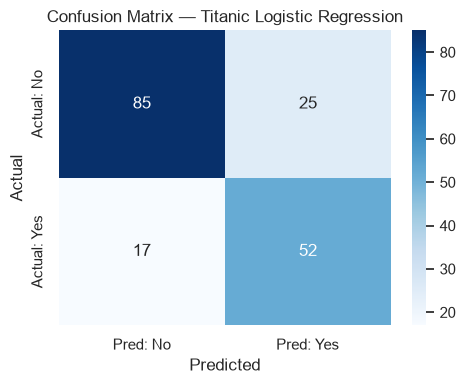

In [44]:
import seaborn as sns

# Visualize the confusion matrix as a heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'], ax=ax)
plt.title("Confusion Matrix — Titanic Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

AUC: 0.8444


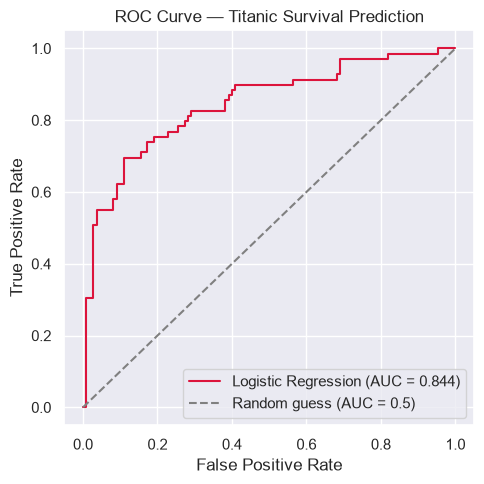

In [45]:
# ROC curve + AUC — sweep the decision threshold and plot TPR vs FPR
y_prob = lr_model.predict_proba(X_test)[:, 1]   # probability of class '1' (Survived)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print(f"AUC: {auc:.4f}")

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='crimson', label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Titanic Survival Prediction")
plt.legend()
plt.tight_layout()
plt.show()

**Reading the results:** F1 (~0.71) sits between precision (0.675) and recall (0.754) as expected —
it penalizes the model for not being simultaneously excellent at both. The confusion matrix shows
where the mistakes concentrate (false negatives = predicted "did not survive" but actually did —
costly if you cared more about *finding* survivors). The AUC (~0.84) says the model ranks a
randomly chosen survivor above a randomly chosen non-survivor about 84% of the time — a solid
score, well above the 0.5 you'd get from random guessing, and it doesn't depend on picking any one
threshold like 0.5. **এই AUC সংখ্যাটা বলে দেয় মডেল কতটা ভালোভাবে দুই ক্লাসকে আলাদা করতে পারছে, থ্রেশহোল্ড না বদলিয়েই।**

### 2. Decision Boundary Visualization (2 Features)

The full `lr_model` pipeline uses 15 preprocessed columns — impossible to plot directly. To *see*
the decision boundary, we fit a **separate, smaller** logistic regression on just two raw,
human-readable features: `Age` and `Fare`. This is purely for visualization; it will not match
the full model's accuracy (fewer features = less signal), but it makes the sigmoid's S-curve
concrete: instead of a 1D curve, in 2D the boundary becomes a **line** (or curve, with polynomial
features) separating the "probability > 0.5" region from the "probability < 0.5" region.

In [46]:
# Take just 2 raw features for a plottable model
db_cols = ['Age', 'Fare']
X_train_2d = X_train[db_cols].copy()
X_test_2d = X_test[db_cols].copy()

# Impute + scale (same idea as the full pipeline, just for 2 columns)
db_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_train_2d_scaled = db_pipeline.fit_transform(X_train_2d)
X_test_2d_scaled = db_pipeline.transform(X_test_2d)

db_model = LogisticRegression(class_weight='balanced')
db_model.fit(X_train_2d_scaled, y_train)

print("2-feature (Age, Fare) model — test accuracy:",
      accuracy_score(y_test, db_model.predict(X_test_2d_scaled)))

2-feature (Age, Fare) model — test accuracy: 0.6368715083798883


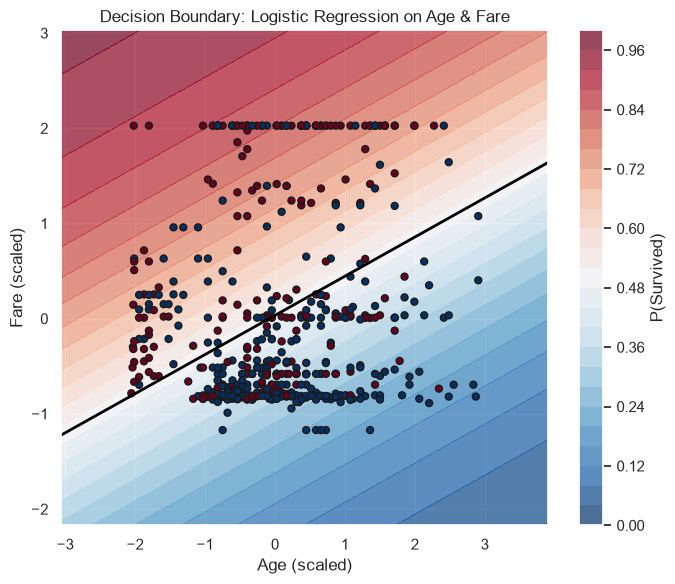

In [47]:
# Build a mesh grid across the scaled Age/Fare space and predict P(Survived) everywhere
x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

Z = db_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 6))
contour = plt.contourf(xx, yy, Z, levels=25, cmap='RdBu_r', alpha=0.7)
plt.colorbar(contour, label='P(Survived)')
# The 0.5-probability contour IS the decision boundary
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], c=y_train,
            cmap='RdBu_r', edgecolor='k', s=25)
plt.xlabel("Age (scaled)")
plt.ylabel("Fare (scaled)")
plt.title("Decision Boundary: Logistic Regression on Age & Fare")
plt.tight_layout()
plt.show()

**Reading the plot:** the black line is exactly where the model's predicted probability equals
`0.5` — the decision boundary. Everywhere on the red side, the model predicts "did not survive";
everywhere on the blue side, "survived". Because logistic regression's `z = w·x + b` is *linear*
in the (scaled) features, that boundary is a **straight line** — this is the core limitation
covered later in the README ("assumes a linear decision boundary in log-odds space"). Notice this
2-feature model's test accuracy is lower than the full 15-column pipeline: `Age`/`Fare` alone
don't carry all the signal that `Sex`, `Pclass`, `Deck`, etc. provide.
**দুটো ফিচার দিয়ে পুরো ছবিটা দেখা যায়, কিন্তু বাস্তব মডেলে সব ফিচার মিলিয়েই ভালো ফল পাওয়া যায়।**

### 3. The `C` Trade-off, Isolated — Train vs. Test Accuracy

Part 3, Section 4 already showed that `||w||` grows with `C`. But to actually **see** under-fitting
and over-fitting, we need *both* train and test accuracy side-by-side across a wide range of `C`
(from very strong to essentially no regularization). The textbook pattern:

- **Very small `C`** (strong regularization) → the model is forced to stay too simple → both train
  and test accuracy are low → **under-fitting**.
- **Very large `C`** (weak/no regularization) → the model is free to fit training noise → train
  accuracy keeps climbing while test accuracy stalls or drops → the growing **gap** between the two
  curves is the signature of **over-fitting**.
- **The sweet spot** is usually somewhere in the middle, chosen by cross-validation in real projects.

In [48]:
# Sweep C across many orders of magnitude and record BOTH train and test accuracy
C_values = np.logspace(-4, 4, 15)
train_accs, test_accs = [], []

for C in C_values:
    model_c = LogisticRegression(C=C, max_iter=2000, class_weight='balanced')
    model_c.fit(X_train_proc, y_train)
    train_accs.append(accuracy_score(y_train, model_c.predict(X_train_proc)))
    test_accs.append(accuracy_score(y_test, model_c.predict(X_test_proc)))

for c, tr, te in zip(C_values, train_accs, test_accs):
    print(f"C={c:<10.5f} train_acc={tr:.3f}   test_acc={te:.3f}   gap={tr - te:+.3f}")

C=0.00010    train_acc=0.791   test_acc=0.743   gap=+0.048
C=0.00037    train_acc=0.791   test_acc=0.749   gap=+0.042
C=0.00139    train_acc=0.791   test_acc=0.754   gap=+0.036
C=0.00518    train_acc=0.792   test_acc=0.754   gap=+0.038
C=0.01931    train_acc=0.794   test_acc=0.760   gap=+0.034
C=0.07197    train_acc=0.799   test_acc=0.760   gap=+0.040
C=0.26827    train_acc=0.799   test_acc=0.754   gap=+0.045
C=1.00000    train_acc=0.798   test_acc=0.765   gap=+0.032
C=3.72759    train_acc=0.799   test_acc=0.765   gap=+0.034
C=13.89495   train_acc=0.798   test_acc=0.777   gap=+0.021
C=51.79475   train_acc=0.796   test_acc=0.777   gap=+0.019
C=193.06977  train_acc=0.798   test_acc=0.777   gap=+0.021
C=719.68567  train_acc=0.796   test_acc=0.777   gap=+0.019
C=2682.69580 train_acc=0.796   test_acc=0.777   gap=+0.019
C=10000.00000 train_acc=0.798   test_acc=0.777   gap=+0.021


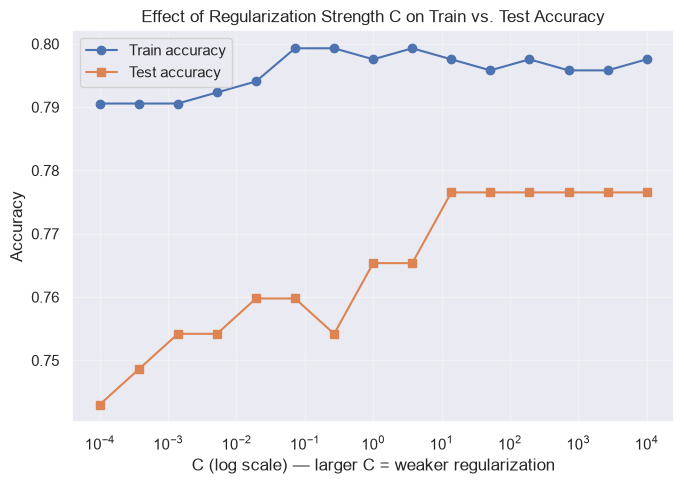

In [49]:
plt.figure(figsize=(7, 5))
plt.plot(C_values, train_accs, marker='o', label='Train accuracy')
plt.plot(C_values, test_accs, marker='s', label='Test accuracy')
plt.xscale('log')
plt.xlabel("C (log scale) — larger C = weaker regularization")
plt.ylabel("Accuracy")
plt.title("Effect of Regularization Strength C on Train vs. Test Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the curves:** at the smallest `C` values, both train and test accuracy sit a few points
lower than their eventual plateau — mild **under-fitting**, since the heavy penalty keeps the
weights near zero regardless of what the data says. As `C` increases, both curves rise and level
off. On this particular dataset the train/test **gap stays fairly small** throughout — Titanic with
only ~15 preprocessed features and a modest sample size doesn't give logistic regression enough
room to badly overfit even at `C=10000`. That's a useful, honest lesson too: **not every dataset
will show textbook over-fitting** — the shape of the curve (does the gap widen at high `C`?) is
what you check for, not a guaranteed outcome. On a dataset with many more (especially noisy or
correlated) features, the train curve would keep climbing while the test curve flattens or drops,
opening a visible gap. **`C` কমালে মডেল সহজ ও কম নির্ভুল হয় (under-fitting), বাড়ালে মডেল ট্রেনিং ডেটার সাথে বেশি মিলে যায় — বড় ডেটাসেটে এটা over-fitting-এর দিকে যেতে পারে।**

### 4. Multiclass Logistic Regression — Softmax (Multinomial) vs. One-vs-Rest

Titanic's target is binary (`survived` / `did not survive`), so it can't show *multiclass*
logistic regression. To cover that, we switch datasets to the classic **Iris** flower dataset
(3 species — `setosa`, `versicolor`, `virginica`), using `petal length` and `petal width` as the
two (plottable) features.

There are two mathematical ways to extend binary logistic regression to more than 2 classes:

- **One-vs-Rest (OvR)**: train one independent binary logistic regression per class ("is it class
  k, or not?"). Each sub-model is fit completely independently, with its own decision boundary;
  scikit-learn's `predict_proba` then rescales the K independent probabilities so they sum to 1
  for convenience, but the underlying models never "talked to each other" while training.
- **Multinomial / Softmax**: train **one joint model** with a separate weight vector per class,
  and convert the raw scores `z_1, z_2, ..., z_K` into probabilities all at once with the **softmax**
  function:

$$P(y = k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

  Here the normalization is built into the training objective itself (not bolted on afterward),
  which is why softmax is generally considered the more statistically principled choice for
  mutually-exclusive classes.

**Version note:** older scikit-learn exposed this choice via `LogisticRegression(multi_class='multinomial')`
vs. `multi_class='ovr'`. In the scikit-learn installed here (1.9.0), the **`multi_class` parameter
has been removed entirely** — `inspect.signature` in Part 3, Section 10 already showed the full,
current parameter list without it. Today, plain `LogisticRegression()` fits the softmax/multinomial
form directly whenever the solver supports it (the modern default behavior), and explicit
one-vs-rest must be requested by wrapping the estimator in `sklearn.multiclass.OneVsRestClassifier`.

In [50]:
from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier

iris = load_iris()
Xi = iris.data[:, 2:4]   # petal length, petal width -> 2 features, easy to plot
yi = iris.target         # 0=setosa, 1=versicolor, 2=virginica -- 3 classes

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    Xi, yi, test_size=0.2, random_state=42, stratify=yi
)

scaler_i = StandardScaler()
Xi_train_s = scaler_i.fit_transform(Xi_train)
Xi_test_s = scaler_i.transform(Xi_test)

print("Classes:", iris.target_names)
print("Train shape:", Xi_train_s.shape, " Test shape:", Xi_test_s.shape)

Classes: ['setosa' 'versicolor' 'virginica']
Train shape: (120, 2)  Test shape: (30, 2)


In [51]:
# Modern default: LogisticRegression fits the joint softmax/multinomial form directly
softmax_model = LogisticRegression(max_iter=1000)
softmax_model.fit(Xi_train_s, yi_train)
softmax_acc = accuracy_score(yi_test, softmax_model.predict(Xi_test_s))
print(f"Softmax/multinomial LogisticRegression — test accuracy: {softmax_acc:.3f}")
print("classes_:", softmax_model.classes_)
print("coef_ shape (one row per class):", softmax_model.coef_.shape)

# Explicit One-vs-Rest: wrap the same base estimator
ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr_model.fit(Xi_train_s, yi_train)
ovr_acc = accuracy_score(yi_test, ovr_model.predict(Xi_test_s))
print(f"One-vs-Rest LogisticRegression   — test accuracy: {ovr_acc:.3f}")

# Both report probabilities that sum to 1 per row (OvR rescales its K independent
# sub-model probabilities to do so) -- the real difference is HOW those numbers were
# produced during training: one joint softmax fit vs. K independently-fit binary models.
sample_probs_softmax = softmax_model.predict_proba(Xi_test_s[:3])
sample_probs_ovr = ovr_model.predict_proba(Xi_test_s[:3])
print("\nSoftmax probs:\n", sample_probs_softmax, "\nrow sums:", sample_probs_softmax.sum(axis=1))
print("\nOvR probs:\n", sample_probs_ovr, "\nrow sums:", sample_probs_ovr.sum(axis=1))

Softmax/multinomial LogisticRegression — test accuracy: 0.933
classes_: [0 1 2]
coef_ shape (one row per class): (3, 2)
One-vs-Rest LogisticRegression   — test accuracy: 0.900

Softmax probs:
 [[9.70197035e-01 2.98016494e-02 1.31608775e-06]
 [1.54691155e-03 3.51413654e-01 6.47039434e-01]
 [2.16620279e-01 7.74669008e-01 8.71071265e-03]] 
row sums: [1. 1. 1.]

OvR probs:
 [[8.16423206e-01 1.83539784e-01 3.70104481e-05]
 [3.21564503e-03 3.48411014e-01 6.48373341e-01]
 [3.85764125e-01 5.92957456e-01 2.12784189e-02]] 
row sums: [1. 1. 1.]


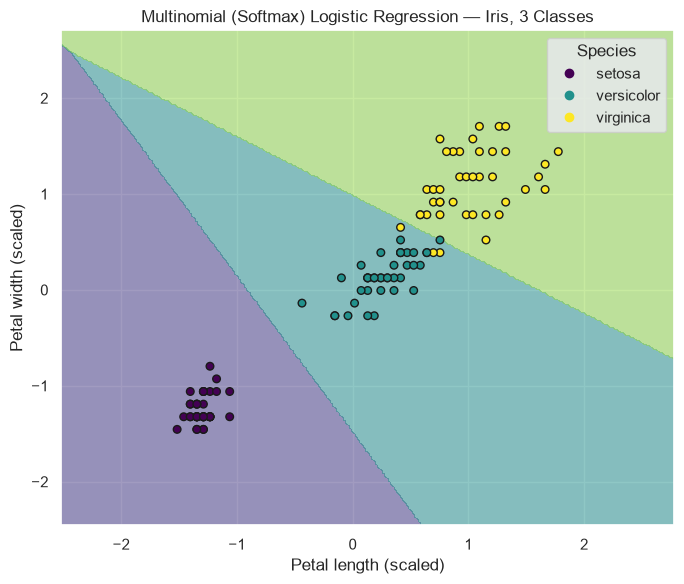

In [52]:
# Visualize the softmax model's 3-class decision regions
x_min, x_max = Xi_train_s[:, 0].min() - 1, Xi_train_s[:, 0].max() + 1
y_min, y_max = Xi_train_s[:, 1].min() - 1, Xi_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

Zi = softmax_model.predict(np.c_[xx.ravel(), yy.ravel()])
Zi = Zi.reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Zi, levels=[-0.5, 0.5, 1.5, 2.5], cmap='viridis', alpha=0.5)
scatter = plt.scatter(Xi_train_s[:, 0], Xi_train_s[:, 1], c=yi_train, cmap='viridis',
                       edgecolor='k', s=30)
plt.xlabel("Petal length (scaled)")
plt.ylabel("Petal width (scaled)")
plt.title("Multinomial (Softmax) Logistic Regression — Iris, 3 Classes")
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names), title="Species")
plt.tight_layout()
plt.show()

**Reading the results:** both the softmax model and the OvR wrapper land on similar (typically
very high, ~90%+) accuracy on Iris, because petal length/width alone separate the three species
almost linearly. Note the decision plot now shows **three** regions instead of two — each boundary
between neighboring regions is still a straight line (or a piece of one), because logistic
regression's decision boundaries are always linear in the feature space, no matter how many
classes. **এখানে তিনটা ক্লাস আছে, তাই "থ্রেশহোল্ড ০.৫"-এর বদলে যেই ক্লাসের প্রব্যাবিলিটি সবচেয়ে বেশি, সেটাই চূড়ান্ত prediction হয়।** This closes the loop on logistic regression as a fully general
classifier — binary (Titanic) and multiclass (Iris) both follow from the exact same sigmoid /
softmax + log-loss + gradient-descent machinery built from scratch in Part 1.

---
# Summary & Key Takeaways

1. **The model**: Logistic Regression predicts a *probability* via $\sigma(W \cdot X + b)$, then thresholds it (usually at 0.5) to get a class label.

2. **The cost function** (Binary Cross-Entropy / Log Loss) penalizes confident wrong predictions heavily — built from scratch in Part 1's `compute_cost()`.

3. **Gradient Descent** (Part 1) and scikit-learn's solvers (Part 2, Section 6) both do the same job: iteratively adjust `W`/`b` to shrink that cost. Part 1 proved it by hand — the final weights correctly reproduced the toy dataset's true labels.

4. **The full pipeline** (Part 2) — feature engineering (`Family_Size`, `Deck`), outlier handling (Z-score / IQR), a `ColumnTransformer` combining imputers/encoders/scalers, and `LogisticRegression` wrapped in one `Pipeline` — took the raw Titanic CSV to a tested ~76.5% test accuracy.

5. **Hyperparameters vs. parameters** (Part 3): `W`/`b`/`coef_`/`intercept_` are *learned*; `C`, `l1_ratio`, `solver`, `class_weight`, `max_iter` are *chosen by you* beforehand.

6. **Tuning priority**: start with `C` (regularization strength), reach for `class_weight='balanced'` (or custom weights) if your classes are imbalanced, and only touch `solver`/`max_iter`/`tol` if you hit a compatibility error or a `ConvergenceWarning`.

7. **One modern gotcha worth remembering**: `penalty` is deprecated in recent scikit-learn — use `l1_ratio` (`0`=l2, `1`=l1, in-between=elasticnet) and `C` instead.

8. **Full evaluation suite** (Part 4): accuracy/precision/recall alone are not enough — F1-score, the confusion matrix, and the ROC curve/AUC (~0.84 here) round out the picture, especially with imbalanced classes.

9. **Decision boundaries are linear** (Part 4): visualized directly on `Age`/`Fare`, the 0.5-probability contour is a straight line — the geometric meaning of "logistic regression assumes a linear relationship in log-odds space."

10. **The `C` trade-off, isolated** (Part 4): plotting train *and* test accuracy together across a wide `C` range is how you actually diagnose under-fitting (both low, small `C`) vs. over-fitting (train ≫ test, large `C`) rather than just tracking one number.

11. **Multiclass logistic regression is not a different algorithm** (Part 4): the Iris demo shows the same sigmoid/log-loss/gradient-descent machinery generalizes to 3+ classes via the **softmax** function, with One-vs-Rest as the classic (now less common, since `multi_class` was removed from scikit-learn) alternative.

12. **What logistic regression is *not* for**: it is a classification-only algorithm. For predicting a continuous, unbounded target, use **Linear Regression** instead (see the sibling folder `Supervised/Linear Regression - Simple & Multiple (Regression)`) — this README's companion `README.md` explains why in detail.